## 0. 분석 모집단 정의 및 표본설계

DA-01에서는 전체 Ethereum 거래를 그대로 분석에 사용하는 것이 아니라,
FPG Runtime 검증 목적에 적합한 분석 모집단과 표본을 먼저 정의한다.

Ethereum의 거래 형식은 전체 기간 동안 동일하게 유지되지 않았기 때문에,
우선 `transaction_type`의 월별 구성비를 확인하여 전체 역사 데이터를 하나의 동일한 모집단으로 볼 수 있는지 검증한다.

이후 현재 Ethereum 환경에서 실제로 공존하는 Transaction Type을 확인하고,
이를 기준으로 최종 분석 모집단과 표본추출 방식을 결정한다.

따라서 본 단계의 전처리는 단순 결측치·중복치 제거가 아니라,

**모집단 구조 확인 → 현재 분석대상 정의 → 표본크기 산정 → 층화표본 설계**

과정을 중심으로 수행한다.

### Transaction Type 설명

Ethereum의 `transaction_type`은 거래가 어떤 형식으로 만들어졌는지를 나타낸다.

| Type | 쉬운 설명 | 주요 특징 |
|---|---|---|
| **Type 0** | 초기부터 사용된 기본 거래 형식 | 기존 방식의 가스비 구조 사용 |
| **Type 1** | 스마트컨트랙트 접근 정보를 미리 지정하는 거래 | Access List를 사용해 접근할 주소·저장공간을 명시 |
| **Type 2** | 현재 가장 일반적인 수수료 방식의 거래 | 기본 수수료와 우선 수수료를 분리한 EIP-1559 방식 |
| **Type 3** | 대용량 데이터를 효율적으로 처리하기 위한 거래 | Layer 2 데이터 게시 등에 사용하는 Blob 기능 추가 |
| **Type 4** | 일반 계정에 스마트컨트랙트 기능을 위임할 수 있는 최신 거래 | 계정 권한 위임을 지원하는 EIP-7702 방식 |

즉, Type 번호는 거래의 위험도나 성공 여부를 의미하는 것이 아니라  
**Ethereum이 발전하면서 추가된 서로 다른 거래 형식**을 의미한다.

따라서 시기별 Type 구성비가 달라진다는 것은 Ethereum 거래 데이터의 구조 자체가 시간에 따라 변화했다는 뜻이다.

In [7]:
QUERY_TYPE_MONTHLY = f"""
SELECT
    DATE_TRUNC(DATE(block_timestamp), MONTH) AS month,
    transaction_type,
    COUNT(*) AS transaction_count
FROM `{DATASET}.transactions`
WHERE transaction_type IS NOT NULL
GROUP BY month, transaction_type
ORDER BY month, transaction_type
"""

dry_config = bigquery.QueryJobConfig(
    dry_run=True,
    use_query_cache=False
)

dry_job = client.query(
    QUERY_TYPE_MONTHLY,
    job_config=dry_config,
    location="US"
)

print(
    f"월별 Transaction Type 전체기간 집계 예상 처리량: "
    f"{dry_job.total_bytes_processed / 1024**3:.2f} GiB"
)

월별 Transaction Type 전체기간 집계 예상 처리량: 55.48 GiB


### 1.1 전체 기간 Transaction 구조 변화 확인

전체 Ethereum 거래를 월별 `transaction_type` 구성비로 집계하여 시간에 따른 거래 구조 변화를 확인한다.

이 단계의 목적은 **2015~2026년 전체 거래를 하나의 동일한 구조를 가진 모집단으로 볼 수 있는지 판단하는 것**이다.

거래유형의 구성비가 시기별로 크게 달라진다면 전체 역사 데이터를 그대로 하나의 모집단으로 사용하지 않고, 이후 **현재 Ethereum 환경에서 실제로 함께 사용되는 Transaction Type을 기준으로 최종 모집단과 표본설계를 결정한다.**

In [8]:
job = client.query(
    QUERY_TYPE_MONTHLY,
    location="US"
)

df_type_monthly = job.to_dataframe()

print(
    f"실제 처리량: "
    f"{job.total_bytes_processed / 1024**3:.2f} GiB"
)

print(f"집계 결과 행 수: {len(df_type_monthly):,}")

display(df_type_monthly.head(20))

C:\Users\user\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


실제 처리량: 55.48 GiB
집계 결과 행 수: 310


,month,transaction_type,transaction_count
0,2015-08-01,0,85609
1,2015-09-01,0,173805
2,2015-10-01,0,205045
3,2015-11-01,0,234733
4,2015-12-01,0,347092
5,2016-01-01,0,404816
6,2016-02-01,0,520040
7,2016-03-01,0,917170
8,2016-04-01,0,1023096
9,2016-05-01,0,1346796


### 1.2 Transaction Type 구성 변화 시각화

월별 `transaction_type` 구성비를 시각화하여 Ethereum의 거래 형식이 시간에 따라 어떻게 변화했는지 확인한다.

이 단계에서는 **전체 역사 데이터를 하나의 동일한 구조를 가진 모집단으로 사용할 수 있는지** 시각적으로 판단한다.

시기별 거래유형 구성이 뚜렷하게 다르게 나타날 경우, 전체 기간을 그대로 표본 모집단으로 사용하지 않는다.

이후 **현재 Ethereum 환경에서 실제로 공존하는 Transaction Type을 확인한 뒤**, FPG Runtime 분석에 적합한 최종 모집단과 표본추출 방식을 결정한다.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import platform
from pathlib import Path

# 한글 폰트
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

NAVY_PALETTE = [
    "#071A2D",
    "#0B2D4D",
    "#124A73",
    "#1D6591",
    "#337FA8",
    "#5799BF",
    "#83B5D1"
]

df_type_monthly["month"] = pd.to_datetime(df_type_monthly["month"])

type_pivot = (
    df_type_monthly
    .pivot(
        index="month",
        columns="transaction_type",
        values="transaction_count"
    )
    .fillna(0)
    .sort_index()
)

type_ratio = type_pivot.div(
    type_pivot.sum(axis=1),
    axis=0
) * 100

TYPE_LABEL = {
    0: "Type 0 · Legacy",
    1: "Type 1 · Access List",
    2: "Type 2 · EIP-1559",
    3: "Type 3 · Blob",
    4: "Type 4"
}

print("확인된 Transaction Type:", list(type_ratio.columns))
display(type_ratio.tail())

확인된 Transaction Type: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


transaction_type,0,1,2,3,4
month,,,,,
2026-05-01,10.617994,0.104634,87.720805,0.415328,1.141239
2026-06-01,11.809853,0.090196,86.683717,0.495505,0.920728
2026-07-01,10.038429,0.101815,88.42724,0.468564,0.963951
2026-08-01,10.56731,0.070458,87.59512,0.542471,1.224642
2026-09-01,16.842379,0.062893,80.747812,0.798699,1.548217


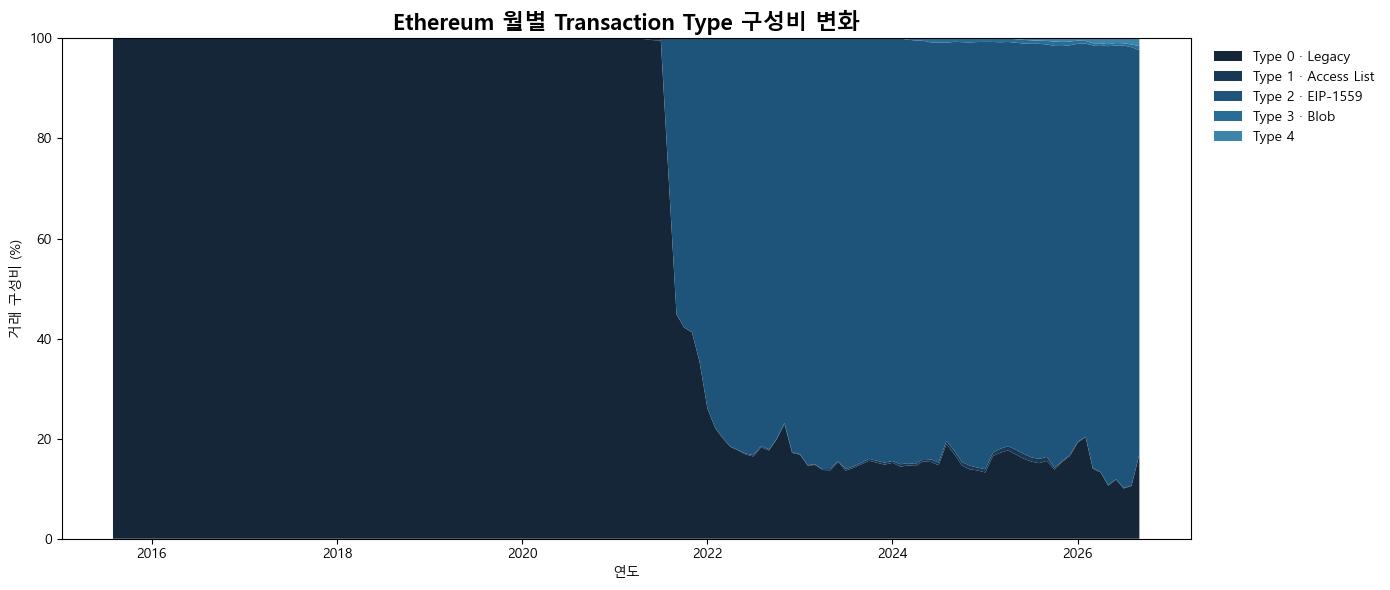

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

labels = [
    TYPE_LABEL.get(x, f"Type {x}")
    for x in type_ratio.columns
]

ax.stackplot(
    type_ratio.index,
    *[
        type_ratio[col].values
        for col in type_ratio.columns
    ],
    labels=labels,
    colors=NAVY_PALETTE[:len(type_ratio.columns)],
    alpha=0.95
)

ax.set_title(
    "Ethereum 월별 Transaction Type 구성비 변화",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("연도")
ax.set_ylabel("거래 구성비 (%)")

ax.set_ylim(0, 100)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False
)

plt.tight_layout()
plt.show()

### 해석

Ethereum의 거래 방식은 전체 기간 동안 동일하게 유지되지 않았다.

초기에는 Ethereum이 처음부터 사용해 온 기본 거래 형식인 `Type 0`이 대부분을 차지했지만, 2021년 이후 새로운 수수료 체계가 적용된 `Type 2` 거래가 빠르게 증가하면서 전체 거래 구성 자체가 크게 변화하였다.

즉, 2015년의 Ethereum 거래와 현재 Ethereum 거래를 동일한 구조의 데이터로 보기 어렵다.

따라서 2015~2026년 전체 거래를 하나의 동일한 모집단으로 간주하여 그대로 표본추출하는 방식은 적절하지 않다.

다만 이 결과만으로 과거의 각 시기를 모두 층화 기준으로 사용할 필요가 있다고 결론내리지는 않는다.

FPG는 현재의 Ethereum 외부 실행환경을 대상으로 하므로, 다음 단계에서는 **현재 Ethereum 환경에서 Type 0~4 거래가 실제로 함께 사용되고 있는지 확인한다.**

이를 바탕으로 현재 거래유형이 여러 개 공존한다면 **현재 환경을 모집단으로 제한한 뒤 Transaction Type별 층화표본을 구성하고**, 특정 Type이 사실상 단독으로 사용된다면 해당 Type을 중심으로 최종 분석 모집단을 설정한다.

### 1.3 Transaction Type별 등장 시점과 구성 변화

누적 구성비 그래프에서는 비중이 작은 Transaction Type의 변화가 잘 드러나지 않으므로,
월별 구성비를 Heatmap으로 확인한다.

이를 통해 각 Transaction Type이 **언제 등장했고, 이후 현재까지 어떤 비중으로 공존하고 있는지** 확인한다.

이 결과는 과거 전체 기간의 구조 변화 자체보다, **현재 Ethereum 환경에서 여러 거래유형이 동시에 사용되는지 판단하기 위한 근거**로 활용한다.

Heatmap dtype: float64
Heatmap shape: (5, 134)


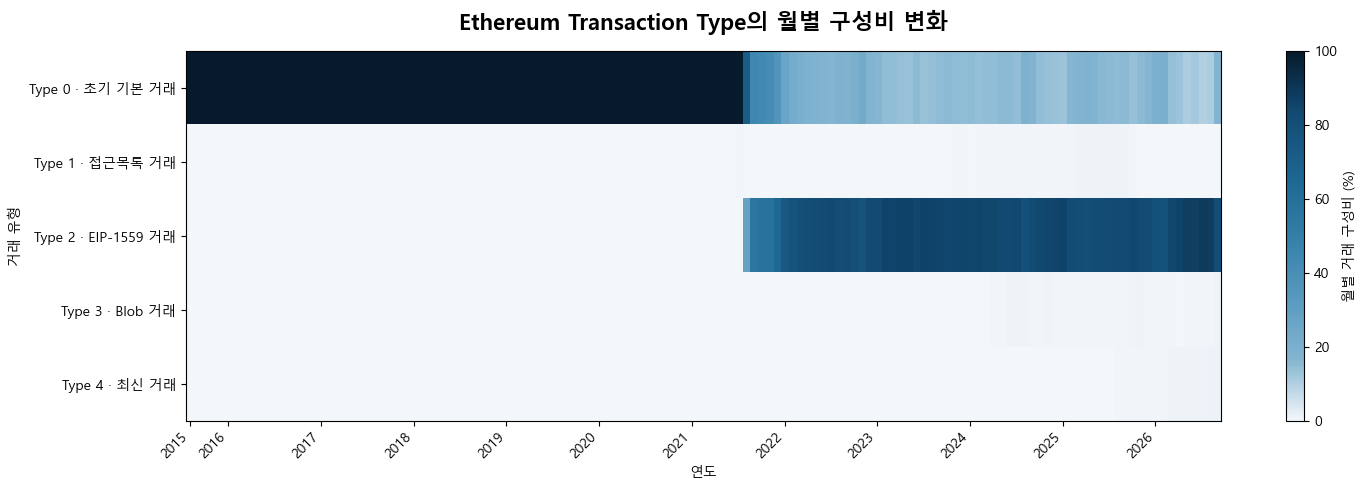

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 01. Heatmap용 데이터 숫자형으로 변환
heatmap_df = type_ratio.T.copy()

heatmap_df = heatmap_df.apply(
    pd.to_numeric,
    errors="coerce"
).fillna(0)

heatmap_values = heatmap_df.to_numpy(dtype=float)

print("Heatmap dtype:", heatmap_values.dtype)
print("Heatmap shape:", heatmap_values.shape)


# 02. Transaction Type 한글 라벨
TYPE_LABEL = {
    0: "Type 0 · 초기 기본 거래",
    1: "Type 1 · 접근목록 거래",
    2: "Type 2 · EIP-1559 거래",
    3: "Type 3 · Blob 거래",
    4: "Type 4 · 최신 거래"
}


# 03. 남색 Heatmap Palette
navy_cmap = mcolors.LinearSegmentedColormap.from_list(
    "navy_gradient",
    [
        "#F4F7FA",
        "#83B5D1",
        "#5799BF",
        "#337FA8",
        "#1D6591",
        "#124A73",
        "#071A2D"
    ]
)


# 04. Heatmap
fig, ax = plt.subplots(figsize=(15, 5))

im = ax.imshow(
    heatmap_values,
    aspect="auto",
    cmap=navy_cmap,
    interpolation="nearest",
    vmin=0,
    vmax=100
)

ax.set_title(
    "Ethereum Transaction Type의 월별 구성비 변화",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("연도")
ax.set_ylabel("거래 유형")


# 05. Y축 Transaction Type
ax.set_yticks(range(len(heatmap_df.index)))

ax.set_yticklabels([
    TYPE_LABEL.get(int(t), f"Type {t}")
    for t in heatmap_df.index
])


# 06. X축 연도
year_positions = []
year_labels = []

for year in sorted(type_ratio.index.year.unique()):
    idx = np.where(type_ratio.index.year == year)[0]

    if len(idx) > 0:
        year_positions.append(idx[0])
        year_labels.append(str(year))

ax.set_xticks(year_positions)

ax.set_xticklabels(
    year_labels,
    rotation=45,
    ha="right"
)


# 07. Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("월별 거래 구성비 (%)")

plt.tight_layout()
plt.show()

### 해석

월별 거래 유형 구성비를 확인한 결과, Ethereum의 거래 구조는 전체 기간 동안 동일하게 유지되지 않았다.

- 초기에는 `Type 0` 기본 거래가 거의 전체를 차지했다.
- 2021년 이후 `Type 2(EIP-1559)` 거래가 빠르게 증가하면서 거래 구성의 중심이 크게 이동했다.
- `Type 1`, `Type 3`, `Type 4`는 이후 순차적으로 등장했으며 현재 환경에서도 일부 비중을 차지하고 있다.

즉, 과거 전체 기간의 Ethereum 거래를 하나의 동일한 구조를 가진 모집단으로 간주하는 것은 적절하지 않다.

다만 이 결과만으로 과거 시기별 층화표본을 바로 적용하지는 않는다.

FPG는 현재의 Ethereum 외부 실행환경을 대상으로 하므로, 다음 단계에서는 **현재 환경에서 Type 0~4 거래가 실제로 함께 사용되고 있는지 확인하고**, 이를 기준으로 최종 모집단과 표본추출 방식을 결정한다.

또한 본 결과는 시각적 근거이므로, 시기별 Transaction Type 구성 차이가 통계적으로도 유의한지 추가 검증한다.

### 1.4 시기별 Transaction 구조 차이 검증

앞선 시각화에서 Ethereum의 Transaction Type 구성이 시간에 따라 크게 변화하는 것이 확인되었다.

이를 통계적으로 검증하기 위해 주요 Ethereum 업그레이드 시점을 기준으로 기간을 구분하고,
각 시기의 `transaction_type` 분포를 비교한다.

월별 집계 데이터에서는 업그레이드가 발생한 월에 변경 전·후 거래가 함께 포함될 수 있으므로,
해당 전환 월은 비교에서 제외한다.

비교 구간은 다음과 같다.

- Berlin 이전
- Berlin 이후 ~ London 이전
- London 이후 ~ Merge 이전
- Merge 이후 ~ Dencun 이전
- Dencun 이후 ~ Pectra 이전
- Pectra 이후 ~ 현재

#### 검증 목적

전체 Ethereum 역사에서 시기가 달라져도 Transaction Type 구성이 동일한지 확인한다.

#### 가설

**H0 (귀무가설)**  
시기와 Transaction Type은 서로 독립이다.  
즉, 시기가 달라져도 Transaction Type의 구성비는 동일하다.

**H1 (대립가설)**  
시기와 Transaction Type은 서로 독립이 아니다.  
즉, 시기에 따라 Transaction Type의 구성비가 달라진다.

#### 검증 방법

- Chi-square Independence Test
- 기대빈도 조건 확인
- 효과크기: Cramér's V

전체 거래 규모가 매우 크기 때문에 p-value만으로 판단하지 않고,
Cramér's V를 함께 확인하여 실제 구조적 차이의 크기를 평가한다.

이 검정의 목적은 과거 시기별 층화표본을 확정하는 것이 아니라,
**2015~2026년 전체 Ethereum 거래를 하나의 동일한 구조를 가진 모집단으로 사용할 수 있는지 판단하는 것**이다.

최종 표본설계는 이후 현재 Ethereum 환경에서 실제로 공존하는 Transaction Type을 확인한 뒤 결정한다.

In [16]:
import numpy as np
import pandas as pd

df_era = df_type_monthly.copy()

df_era["month"] = pd.to_datetime(df_era["month"])
df_era["transaction_type"] = pd.to_numeric(
    df_era["transaction_type"],
    errors="coerce"
).astype("Int64")


def assign_protocol_era(month):
    # 전환월 제외
    if month < pd.Timestamp("2021-04-01"):
        return "S1. Pre-Berlin"

    elif pd.Timestamp("2021-05-01") <= month < pd.Timestamp("2021-08-01"):
        return "S2. Berlin → London"

    elif pd.Timestamp("2021-09-01") <= month < pd.Timestamp("2022-09-01"):
        return "S3. London → Merge"

    elif pd.Timestamp("2022-10-01") <= month < pd.Timestamp("2024-03-01"):
        return "S4. Merge → Dencun"

    elif pd.Timestamp("2024-04-01") <= month < pd.Timestamp("2025-05-01"):
        return "S5. Dencun → Pectra"

    elif month >= pd.Timestamp("2025-06-01"):
        return "S6. Pectra → 현재"

    return np.nan


df_era["protocol_era"] = df_era["month"].apply(assign_protocol_era)

print("전환월 제외 행:", df_era["protocol_era"].isna().sum())

df_era_clean = df_era.dropna(
    subset=["protocol_era"]
).copy()

전환월 제외 행: 17


In [17]:
ERA_ORDER = [
    "S1. Pre-Berlin",
    "S2. Berlin → London",
    "S3. London → Merge",
    "S4. Merge → Dencun",
    "S5. Dencun → Pectra",
    "S6. Pectra → 현재"
]

era_type_count = (
    df_era_clean
    .groupby(
        ["protocol_era", "transaction_type"],
        as_index=False
    )["transaction_count"]
    .sum()
)

era_type_pivot = (
    era_type_count
    .pivot(
        index="protocol_era",
        columns="transaction_type",
        values="transaction_count"
    )
    .fillna(0)
    .reindex(ERA_ORDER)
)

era_type_ratio = (
    era_type_pivot
    .div(era_type_pivot.sum(axis=1), axis=0)
    * 100
)

display(era_type_ratio.round(3))

transaction_type,0,1,2,3,4
protocol_era,,,,,
S1. Pre-Berlin,100.0,0.0,0.0,0.0,0.0
S2. Berlin → London,99.7,0.3,0.0,0.0,0.0
S3. London → Merge,27.071,0.086,72.844,0.0,0.0
S4. Merge → Dencun,15.689,0.267,84.044,0.0,0.0
S5. Dencun → Pectra,15.543,0.647,83.101,0.71,0.0
S6. Pectra → 현재,14.346,0.293,84.014,0.589,0.759


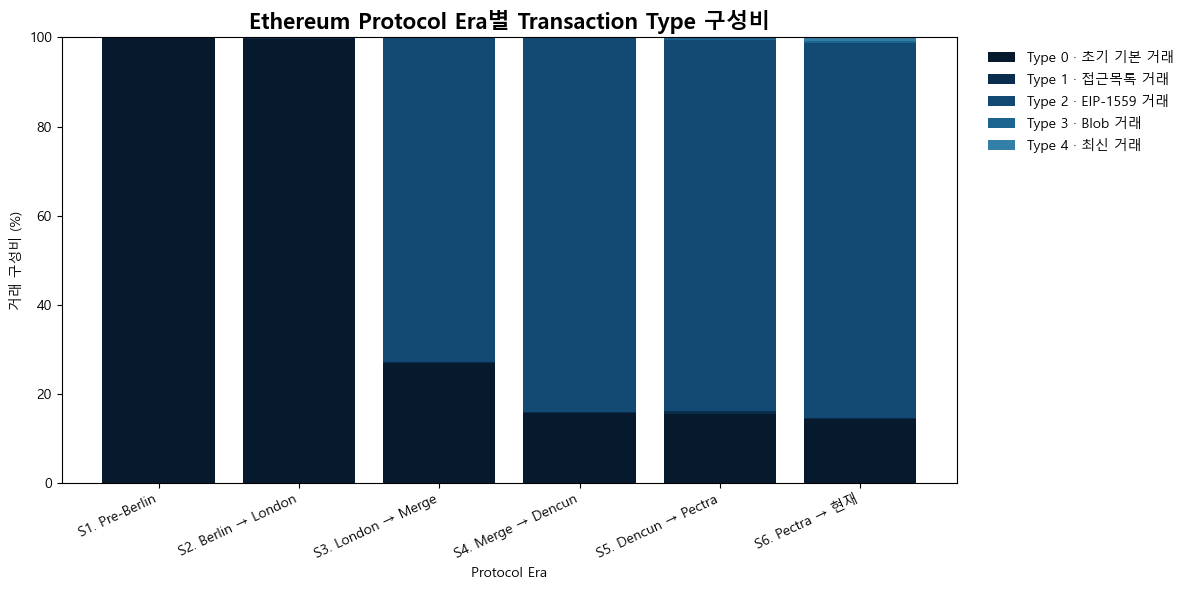

In [18]:
TYPE_LABEL = {
    0: "Type 0 · 초기 기본 거래",
    1: "Type 1 · 접근목록 거래",
    2: "Type 2 · EIP-1559 거래",
    3: "Type 3 · Blob 거래",
    4: "Type 4 · 최신 거래"
}

fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(era_type_ratio))

for i, tx_type in enumerate(era_type_ratio.columns):
    values = era_type_ratio[tx_type].to_numpy(dtype=float)

    ax.bar(
        era_type_ratio.index,
        values,
        bottom=bottom,
        color=NAVY_PALETTE[i],
        label=TYPE_LABEL.get(tx_type, f"Type {tx_type}")
    )

    bottom += values

ax.set_title(
    "Ethereum Protocol Era별 Transaction Type 구성비",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Protocol Era")
ax.set_ylabel("거래 구성비 (%)")
ax.set_ylim(0, 100)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [19]:
from scipy.stats import chi2_contingency
import numpy as np

contingency = era_type_pivot.astype(float)

chi2, p_value, dof, expected = chi2_contingency(
    contingency
)

n = contingency.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 /
    (
        n *
        min(
            contingency.shape[0] - 1,
            contingency.shape[1] - 1
        )
    )
)

expected = np.asarray(expected)

print(f"전체 거래 N     : {int(n):,}")
print(f"Chi-square      : {chi2:,.3f}")
print(f"자유도          : {dof}")

if p_value == 0:
    print("p-value         : < 1e-300")
else:
    print(f"p-value         : {p_value:.6e}")

print(f"Cramér's V      : {cramers_v:.4f}")
print(f"최소 기대빈도   : {expected.min():,.2f}")
print(f"기대빈도 < 5 비율: {(expected < 5).mean() * 100:.2f}%")

전체 거래 N     : 3,529,267,836
Chi-square      : 2,227,904,894.536
자유도          : 20
p-value         : < 1e-300
Cramér's V      : 0.3973
최소 기대빈도   : 228,269.37
기대빈도 < 5 비율: 0.00%


### 1.4 시기별 Transaction 구조 차이 가설검정

#### 검증 목적

Ethereum 전체 역사 데이터를 하나의 동일한 구조를 가진 모집단으로 볼 수 있는지 확인한다.

주요 Ethereum 업그레이드 시점을 기준으로 기간을 구분하고,
각 시기의 `transaction_type` 구성비가 동일한지 검증한다.

#### 가설

**H0 (귀무가설)**  
시기와 Transaction Type은 서로 독립이다.  
즉, 시기가 달라도 Transaction Type의 구성비는 동일하다.

**H1 (대립가설)**  
시기와 Transaction Type은 서로 독립이 아니다.  
즉, 시기에 따라 Transaction Type의 구성비가 달라진다.

#### 검증 방법

- Chi-square Independence Test
- 기대빈도 조건 확인
- 효과크기: Cramér's V

전체 거래 규모가 매우 크기 때문에 p-value만으로 판단하지 않고,
Cramér's V를 함께 확인하여 시기와 Transaction Type 사이의 구조적 연관성 크기를 평가한다.

### 검정 결과

시기별 Transaction Type의 분포 차이를 검정한 결과 통계적으로 유의한 차이가 확인되었다.

- 분석 거래: **3,529,267,836건**
- χ² = **2,227,904,894.536**
- df = **20**
- p < **1e-300**
- Cramér's V = **0.3973**
- 기대빈도 5 미만 Cell: **0%**

모든 Cell이 Chi-square 기대빈도 조건을 충족했으며,
p-value가 매우 작아 **H0를 기각**한다.

즉, Ethereum의 Transaction Type 구성비는 전체 기간 동안 동일하게 유지되지 않았으며,
시기에 따라 거래 구조가 달라진 것으로 확인되었다.

또한 약 35억 건의 대규모 데이터를 사용했기 때문에 통계적 유의성만으로 결론내리지 않고 효과크기를 함께 확인하였다.

Cramér's V = **0.3973**으로 나타나,
시기와 Transaction Type 사이의 차이가 단순히 대규모 표본으로 인해 검출된 미세한 차이에 그치지 않으며
**무시하기 어려운 구조적 연관성이 존재함**을 확인하였다.

### 전처리 결론

시각화와 가설검정 결과를 종합하면,
**2015~2026년 Ethereum 전체 거래를 하나의 동일한 구조를 가진 모집단으로 간주하는 것은 적절하지 않다.**

다만 이 결과는 과거 각 시기를 그대로 층화표본으로 사용해야 한다는 의미는 아니다.

FPG는 현재 Ethereum 외부 실행환경을 대상으로 하므로,
다음 단계에서는 **현재 환경에서 Type 0~4 거래가 실제로 함께 사용되고 있는지 확인한다.**

그 결과를 기준으로 최종 모집단과 표본추출 방식을 결정한다.

- 현재 여러 Transaction Type이 공존하는 경우  
  → 현재 환경을 모집단으로 제한하고 **Transaction Type별 층화표본**을 검토한다.

- 특정 Transaction Type이 사실상 단독으로 사용되는 경우  
  → 해당 Transaction Type을 중심으로 분석 모집단을 구성한다.

따라서 본 검정의 핵심 결론은  
**과거 시기별로 층화한다가 아니라, 전체 역사 데이터를 하나의 모집단으로 그대로 사용하지 않는다**이다.

### 1.5 현재 Ethereum 환경의 Transaction Type 공존 여부 확인

앞선 분석에서 Ethereum의 거래 구조가 전체 역사 동안 동일하지 않았음을 확인하였다.

FPG는 과거 Ethereum 환경이 아니라 **현재 외부 실행환경에서 발생하는 거래를 통제**하는 것이 목적이다.

따라서 최신 Ethereum 환경에서 `Type 0~4` 거래가 실제로 함께 사용되고 있는지 확인한다.

Pectra 업그레이드가 발생한 2025년 5월은 변경 전·후 거래가 함께 포함될 수 있으므로 제외하고,
**2025년 6월 이후를 현재 구조가 적용된 분석 구간**으로 설정한다.

- 여러 Transaction Type이 함께 존재하는 경우  
  → 현재 환경 내 Transaction Type별 표본설계를 검토한다.

- 특정 Transaction Type만 사용되는 경우  
  → 해당 Type을 중심으로 분석 모집단을 설정한다.

In [20]:
# 01. 현재 Ethereum 환경 데이터 추출
df_current = df_type_monthly[
    df_type_monthly["month"] >= pd.Timestamp("2025-06-01")
].copy()

# 02. Transaction Type별 거래 수 집계
current_type_summary = (
    df_current
    .groupby("transaction_type", as_index=False)["transaction_count"]
    .sum()
)

current_total = current_type_summary["transaction_count"].sum()

# 03. 구성비 계산
current_type_summary["비중_pct"] = (
    current_type_summary["transaction_count"]
    / current_total * 100
)

# 04. 쉬운 거래유형 이름 부여
type_labels = {
    0: "Type 0 · 기본 거래",
    1: "Type 1 · 접근목록 거래",
    2: "Type 2 · EIP-1559 거래",
    3: "Type 3 · Blob 거래",
    4: "Type 4 · 권한위임 거래"
}

current_type_summary["거래유형"] = (
    current_type_summary["transaction_type"]
    .map(type_labels)
)

current_type_summary = (
    current_type_summary
    .sort_values("transaction_count", ascending=False)
    .reset_index(drop=True)
)

display(
    current_type_summary[
        ["거래유형", "transaction_count", "비중_pct"]
    ]
)

,거래유형,transaction_count,비중_pct
0,Type 2 · EIP-1559 거래,751117036,84.013664
1,Type 0 · 기본 거래,128256215,14.345667
2,Type 4 · 권한위임 거래,6785739,0.758996
3,Type 3 · Blob 거래,5263226,0.5887
4,Type 1 · 접근목록 거래,2619302,0.292973


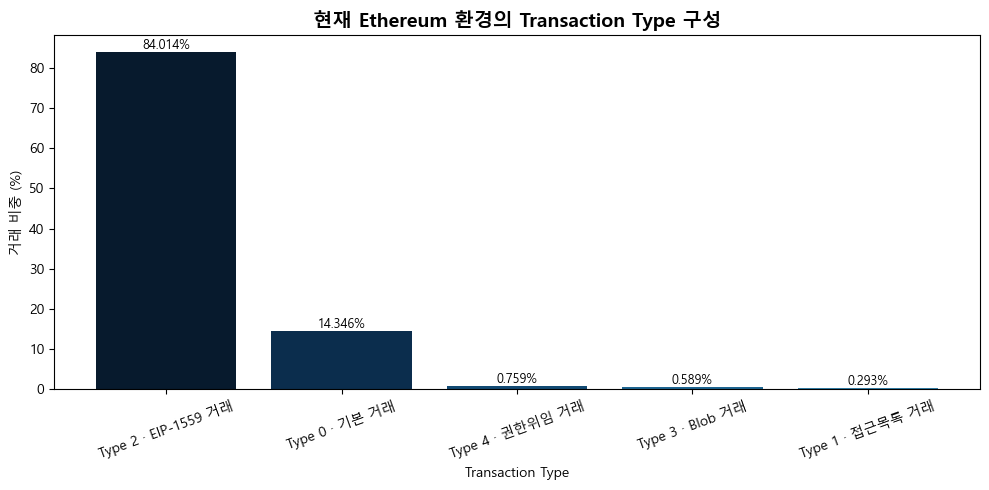

In [21]:
# 05. 현재 Ethereum Transaction Type 구성비 시각화

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    current_type_summary["거래유형"],
    current_type_summary["비중_pct"],
    color=NAVY_PALETTE[:len(current_type_summary)]
)

ax.set_title(
    "현재 Ethereum 환경의 Transaction Type 구성",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Transaction Type")
ax.set_ylabel("거래 비중 (%)")

ax.tick_params(axis="x", rotation=20)

for bar, value in zip(bars, current_type_summary["비중_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### 해석

Pectra 이후 현재 Ethereum 환경의 Transaction Type 구성비를 확인한 결과,
`Type 0~4`가 모두 실제 거래에 사용되고 있는 것으로 나타났다.

- `Type 2(EIP-1559)` : **84.014%**
- `Type 0(기본 거래)` : **14.346%**
- `Type 4(권한위임 거래)` : **0.759%**
- `Type 3(Blob 거래)` : **0.589%**
- `Type 1(접근목록 거래)` : **0.293%**

현재 거래의 대부분은 Type 2가 차지하지만,
이전 Transaction Type도 폐기되지 않고 현재 네트워크에서 함께 사용되고 있다.

따라서 최신 Transaction Type인 Type 4만을 현재 Ethereum 거래의 대표 모집단으로 사용하는 것은 적절하지 않다.

반면 전체 현재 거래에서 단순 임의추출을 수행하면 비중이 작은 Type 1·3·4가 표본에서 충분히 확보되지 않을 가능성이 있다.

이에 따라 DA-01에서는 **Pectra 이후 현재 Ethereum 환경을 분석 모집단으로 설정하고,
Transaction Type을 층(Stratum)으로 사용하는 층화표본추출을 적용한다.**

다만 Type별 실제 모집단 비중이 크게 다르므로,
희소 Transaction Type의 분석 가능성을 확보하기 위해 단순 비례할당이 아닌
**희소 Type을 추가 확보하는 불비례 층화표본**을 검토한다.

전체 Ethereum 거래 수준의 비율을 추정할 때에는 실제 모집단 구성비를 반영한 가중치를 적용한다.

### 1.6 DA-01 표본크기 산정 기준

DA-01의 핵심 검증 대상은 Transaction이 기록되었다는 사실과 실제 Execution Result가 동일한 의미인지 확인하는 것이다.

이를 위해 현재 Ethereum 거래에서 `receipt.status`를 기준으로 Execution 실패 비율을 추정한다.

표본크기는 다음 기준으로 산정한다.

- 신뢰수준: **95%**
- 주요 추정값: **Execution 실패 비율**
- 허용오차: 여러 기준을 비교한 뒤 결정
- 모집단 규모가 매우 크므로 우선 비율 추정을 위한 표본크기 공식을 적용한다.
- 실패율을 사전에 확정할 수 없으므로 보수적 기준(`p=0.5`)과 탐색분석에서 관측된 실패율 수준을 함께 비교한다.

이 단계에서는 먼저 필요한 전체 표본규모를 계산하고,
이후 현재 Transaction Type별 구성비와 희소 Type의 분석 가능성을 고려하여 층별 표본을 배분한다.

In [22]:
# 01. 비율 추정을 위한 표본크기 계산

import pandas as pd
from scipy.stats import norm

CONFIDENCE_LEVEL = 0.95
z = norm.ppf(1 - (1 - CONFIDENCE_LEVEL) / 2)

def proportion_sample_size(p, margin_error):
    return (z**2 * p * (1 - p)) / (margin_error**2)

# 비교할 허용오차
margin_errors = {
    "±0.50%p": 0.005,
    "±0.25%p": 0.0025,
    "±0.10%p": 0.001
}

# p=0.5 : 가장 보수적인 경우
# p=0.013 : 앞선 탐색분석에서 관측된 약 1.3% 실패율 수준
assumed_rates = {
    "보수적 기준 p=0.50": 0.50,
    "탐색 실패율 수준 p=0.013": 0.013
}

rows = []

for rate_name, p in assumed_rates.items():
    for error_name, d in margin_errors.items():

        n = proportion_sample_size(p, d)

        rows.append({
            "기준": rate_name,
            "허용오차": error_name,
            "필요 표본수": int(round(n))
        })

sample_size_table = pd.DataFrame(rows)

display(sample_size_table)

,기준,허용오차,필요 표본수
0,보수적 기준 p=0.50,±0.50%p,38415
1,보수적 기준 p=0.50,±0.25%p,153658
2,보수적 기준 p=0.50,±0.10%p,960365
3,탐색 실패율 수준 p=0.013,±0.50%p,1972
4,탐색 실패율 수준 p=0.013,±0.25%p,7886
5,탐색 실패율 수준 p=0.013,±0.10%p,49290


### 1.7 최종 표본크기 및 층별 배분 기준

비율 추정 공식에 따라 DA-01의 전체 표본크기를 검토한 결과,
탐색분석에서 확인된 약 1.3%의 Execution 실패율을 기준으로
95% 신뢰수준과 ±0.10%p의 허용오차를 확보하기 위해 약 **49,290건**의 표본이 필요한 것으로 나타났다.

따라서 약 5만 건을 전체 모집단의 기본 표본규모로 설정한다.

그러나 현재 Ethereum 거래의 84% 이상이 Type 2에 집중되어 있어
단순 비례할당을 적용할 경우 Type 1·3·4와 같은 희소 거래유형의 표본이 지나치게 적어진다.

이에 따라 다음과 같은 불비례 층화표본 방식을 적용한다.

1. 전체 실패율 추정을 위한 기본 표본은 현재 Transaction Type 구성비를 반영한다.
2. 희소 Transaction Type은 유형별 분석이 가능하도록 최소 표본수를 추가 확보한다.
3. 희소 Type을 과표집하므로 전체 Ethereum 수준의 통계량을 계산할 때는 모집단 비중을 이용한 가중치를 적용한다.

층별 최소 표본은 탐색 실패율 1.3%를 기준으로
각 Type에서 약 100건의 실패 사례를 기대할 수 있는 수준을 사용한다.

약 100건의 실패 사례 확보에 필요한 표본은

`100 / 0.013 ≈ 7,693건`

이므로 실무적 안정성을 고려하여 **Type별 최소 8,000건**을 확보한다.

In [23]:
# 01. 기본 전체 표본크기
BASE_SAMPLE_SIZE = 49290

# 02. 희소 Type 최소 표본
MIN_STRATUM_SAMPLE = 8000

allocation = current_type_summary[
    ["transaction_type", "거래유형", "비중_pct"]
].copy()

# 03. 모집단 비중에 따른 비례할당
allocation["비례표본수"] = (
    BASE_SAMPLE_SIZE * allocation["비중_pct"] / 100
).round().astype(int)

# 04. 각 Type 최소 8,000건 확보
allocation["최종표본수"] = allocation["비례표본수"].clip(
    lower=MIN_STRATUM_SAMPLE
)

display(allocation)

print(
    f"비례할당 기준 표본수: {BASE_SAMPLE_SIZE:,}건"
)

print(
    f"희소 Type 보강 후 실제 추출 표본수: "
    f"{allocation['최종표본수'].sum():,}건"
)

,transaction_type,거래유형,비중_pct,비례표본수,최종표본수
0,2,Type 2 · EIP-1559 거래,84.013664,41410,41410
1,0,Type 0 · 기본 거래,14.345667,7071,8000
2,4,Type 4 · 권한위임 거래,0.758996,374,8000
3,3,Type 3 · Blob 거래,0.5887,290,8000
4,1,Type 1 · 접근목록 거래,0.292973,144,8000


비례할당 기준 표본수: 49,290건
희소 Type 보강 후 실제 추출 표본수: 73,410건


### 표본설계 결과

비율 추정을 위한 기본 표본은 **49,290건**으로 산정되었다.

현재 Ethereum의 Transaction Type 구성비를 적용하여 비례할당한 뒤,
비중이 낮은 거래유형이 분석에서 지나치게 적게 포함되는 문제를 방지하기 위해
Type별 최소 **8,000건**을 확보하였다.

최종 층별 표본은 다음과 같다.

- Type 2 · EIP-1559 거래: **41,410건**
- Type 0 · 기본 거래: **8,000건**
- Type 4 · 권한위임 거래: **8,000건**
- Type 3 · Blob 거래: **8,000건**
- Type 1 · 접근목록 거래: **8,000건**

최종 추출 표본은 총 **73,410건**이다.

Type 1·3·4는 실제 모집단 비중보다 많이 추출되는 불비례 층화표본이므로,
Transaction Type별 비교에는 추출 표본을 그대로 사용하되,
전체 Ethereum 수준의 실패율이나 구성비를 추정할 때에는
각 Type의 실제 모집단 비중을 반영한 **층화 가중치**를 적용한다.

따라서 본 표본은

**현재 Ethereum 환경 한정 → Transaction Type별 층화 → 희소 Type 보강 → 전체 추정 시 가중치 복원**

구조로 설계하였다.

최종 73,410건은 DA-01의 일회성 분석표본이 아니라,
**DA-01~DA-03에서 공통으로 사용하는 Ethereum Master Transaction Sample**로 저장하여
후속 분석의 모집단 기준과 Transaction 기준점을 일관되게 유지한다.

In [32]:
pip install google-cloud-bigquery-storage

In [33]:
# 01. Master Sample 실제 추출

from google.cloud import bigquery
from pathlib import Path
import pandas as pd

# Dry Run 280.83 GiB 기준
MAX_BYTES = 290 * (1024 ** 3)

job_config = bigquery.QueryJobConfig(
    maximum_bytes_billed=MAX_BYTES
)

query_job = client.query(
    query_da01_sample,
    job_config=job_config
)

df_master = query_job.to_dataframe()

print(f"전체 추출 건수: {len(df_master):,}")

전체 추출 건수: 73,410


In [34]:
# 02. Transaction Type별 표본 수 검증

type_check = (
    df_master["transaction_type"]
    .value_counts()
    .sort_index()
    .rename_axis("transaction_type")
    .reset_index(name="sample_count")
)

display(type_check)

print(f"전체: {len(df_master):,}건")
print(f"Transaction Hash 고유값: {df_master['transaction_hash'].nunique():,}건")
print(f"Transaction Hash 중복: {df_master['transaction_hash'].duplicated().sum():,}건")
print(f"Receipt Status 결측: {df_master['receipt_status'].isna().sum():,}건")

,transaction_type,sample_count
0,0,8000
1,1,8000
2,2,41410
3,3,8000
4,4,8000


전체: 73,410건
Transaction Hash 고유값: 73,410건
Transaction Hash 중복: 0건
Receipt Status 결측: 0건


### Master Sample 품질검증 결과

최종 층화표본 **73,410건**을 추출한 뒤 표본의 기본 품질을 검증하였다.

- 전체 표본: **73,410건**
- Type 0: **8,000건**
- Type 1: **8,000건**
- Type 2: **41,410건**
- Type 3: **8,000건**
- Type 4: **8,000건**
- Transaction Hash 고유값: **73,410건**
- Transaction Hash 중복: **0건**
- Receipt Status 결측: **0건**

계획한 Transaction Type별 표본수가 모두 정확하게 확보되었으며,
`transaction_hash` 기준 중복 거래는 존재하지 않았다.

또한 모든 표본 Transaction에 대응하는 Receipt가 확인되어
**Transaction과 Execution Result를 비교하기 위한 DA-01 분석 데이터가 정상적으로 구성되었다.**

따라서 본 73,410건을 Digital Asset 분석의
**Master Transaction Sample**로 확정한다.

이후 DA-01~DA-03은 동일한 Transaction 표본을 기준으로 분석하여
각 분석 간 거래 기준을 일관되게 유지한다.

In [35]:
# 01. Master Transaction Sample 저장

from pathlib import Path

OUTPUT_DIR = Path(
    r"C:\Users\user\Desktop\26.09.01_project\ADP\ADP-DA"
    r"\03_digital_asset\data\processed"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MASTER_CSV = OUTPUT_DIR / "da_master_transaction_sample_73410.csv"

df_master.to_csv(
    MASTER_CSV,
    index=False,
    encoding="utf-8-sig"
)

print(f"저장 완료: {MASTER_CSV}")
print(f"저장 행 수: {len(df_master):,}건")

저장 완료: C:\Users\user\Desktop\26.09.01_project\ADP\ADP-DA\03_digital_asset\data\processed\da_master_transaction_sample_73410.csv
저장 행 수: 73,410건
